# Exploratory Data Analysis (EDA)

The purpose of this notebook is to verify the contents of the IdahoWolfCam folder, which is a subset of the LILAC BC dataset that only contains Wolf imagery. This subset is only to complement the iWildCam2019 dataset.

1. **Target 1: Data Integrity and Channel Auditing:** Ensure that there are no corrupted files. Check if any of the images are gray-scaled. If any of the images are grayscaled, then count the amount for both RGB and grayscaled images.
2. **Target 2: Geometry and Aspect Ratio:** Footage may have been taken from different trail camera models, thus, profile structural variations in pixels across different camera models to design an optimal resizing, padding, or crop augmentation strategies.
3. **Target 3: Spatiotemporal Bursts and Data Leakage Prevention:** Trail Camera footage of animals may be taken in bursts, creating highly similar images. Thus, a problem occurs if such images were split amongst training and testing dataset

## Libraries

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed


## Graphics Configuration and Hardware Allocation

In [8]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

NUM_WORKERS = 8 #cores

JSON_PATH = "/home/greatgilbertsoco/WolfDetect/data/idaho-camera-traps.json"

with open(JSON_PATH, "r") as f:
    data = json.load(f)
df = pd.DataFrame(data, columns=["id", "location", "timestamp", "species", "image_path"])


IMAGE_DIR = Path("/home/greatgilbertsoco/WolfDetect/data/wolf_images")

print(f"Environment ready. Hardware assigned: {NUM_WORKERS} cores are reserved")

# Check how the JSON data is structured
print("JSON Keys found:", data.keys())


if "images" in data:
    df_wolf_metadata = pd.DataFrame(data["images"])
else:
    df_wolf_metadata = pd.DataFrame(data)

local_files = set(os.listdir(IMAGE_DIR)) #Filter local files to only those in the directory

# Create a mapping column to match local filenames
df_wolf_metadata['local_file_name'] = df_wolf_metadata['file_name'].apply(lambda x: os.path.basename(x))
df_wolf = df_wolf_metadata[df_wolf_metadata['local_file_name'].isin(local_files)].copy()

print(f"Total matching local wolf images found in metadata: {len(df_wolf)}")

Environment ready. Hardware assigned: 8 cores are reserved
JSON Keys found: dict_keys(['images', 'annotations', 'categories', 'info'])
Total matching local wolf images found in metadata: 4694


## TARGET 1: File Integrity and Channel Auditing

In [9]:
def inspect_wolf_image(file_name):
    file_path = IMAGE_DIR / file_name
    try:
        with Image.open(file_path) as img:
            img.verify() # File check
            
            with Image.open(file_path) as img_check:
                mode = img_check.mode
                width, height = img_check.size
                
            return file_name, "Valid", mode, width, height
    except Exception:
        return file_name, "Corrupt", None, None, None

# Execute multi-threaded profile inspection
file_list = df_wolf['local_file_name'].tolist()
print(f"Starting analysis on {len(file_list)} local files...")

with ThreadPoolExecutor(max_workers=16) as executor:
    results = list(tqdm(executor.map(inspect_wolf_image, file_list), total=len(file_list), desc="Auditing Assets"))

# Build results dataframe
df_audit = pd.DataFrame(results, columns=['local_file_name', 'Status', 'Mode', 'Width', 'Height'])

Starting analysis on 4694 local files...


Auditing Assets: 100%|██████████| 4694/4694 [00:02<00:00, 2244.00it/s]


--- INTEGRITY & MODE PROFILE ---
Status
Valid    4694
Name: count, dtype: int64
Mode
RGB    4694
Name: count, dtype: int64


/tmp/ipykernel_4729/1211863864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Mode", data=df_audit, order=order, palette="pastel", ax=ax)


Text(0, 0.5, 'Count')

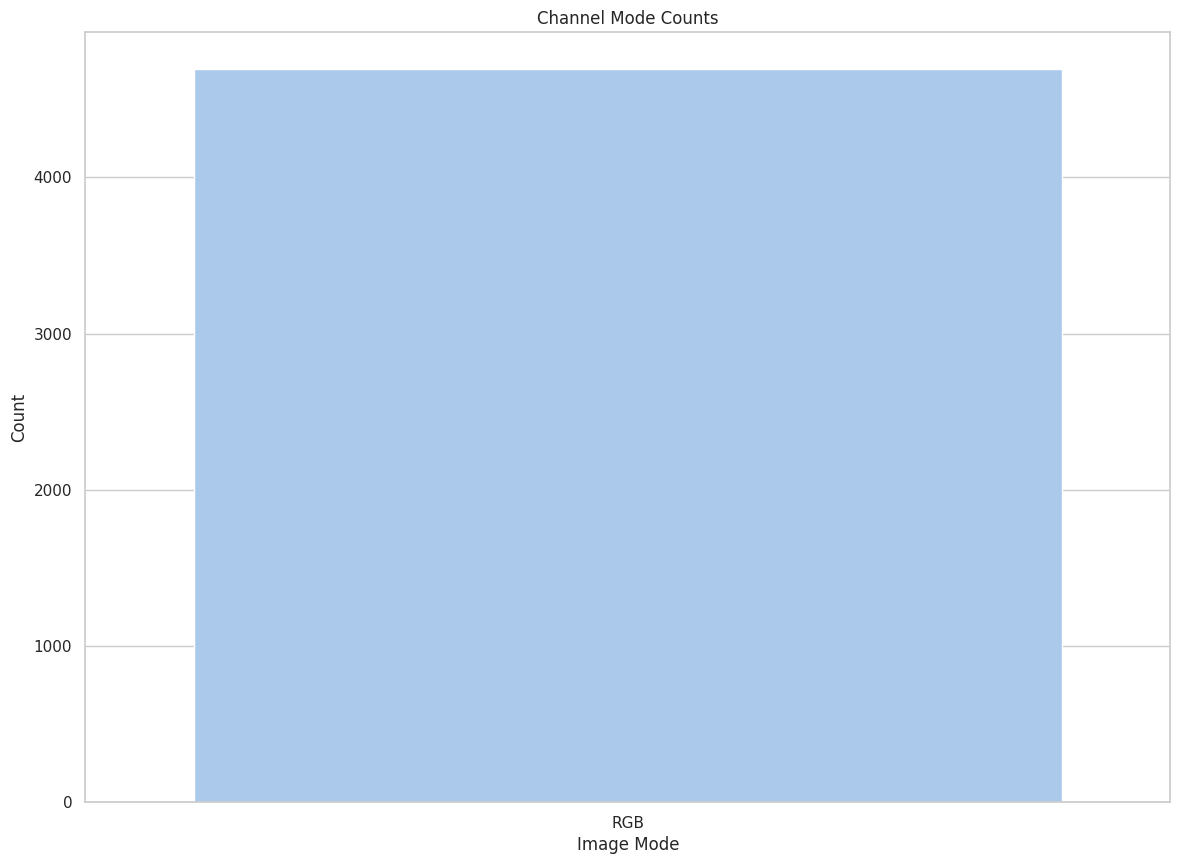

In [18]:
# Check structural health and channel modes
print("--- INTEGRITY & MODE PROFILE ---")
print(df_audit['Status'].value_counts())
print(df_audit['Mode'].value_counts())

# Visualization dashboard for audit & burst summaries
fig, axes = plt.subplots(1, 1, figsize=(14, 10))

ax = axes
order = df_audit["Mode"].value_counts().index
sns.countplot(x="Mode", data=df_audit, order=order, palette="pastel", ax=ax)
ax.set_title("Channel Mode Counts")
ax.set_xlabel("Image Mode")
ax.set_ylabel("Count")



#### Notes:
There are no Grayscaled images.

## TARGET 2 : Geometry and Aspect Ratio Footing


--- GEOMETRIC FOOTPRINT ---
             Width       Height  aspect_ratio
count  4694.000000  4694.000000   4694.000000
mean   3589.481040  2228.916915      1.615869
std     157.803833    88.764656      0.136982
min    3456.000000  2124.000000      1.500000
25%    3456.000000  2124.000000      1.500000
50%    3456.000000  2304.000000      1.500000
75%    3776.000000  2304.000000      1.777778
max    3776.000000  2304.000000      1.777778


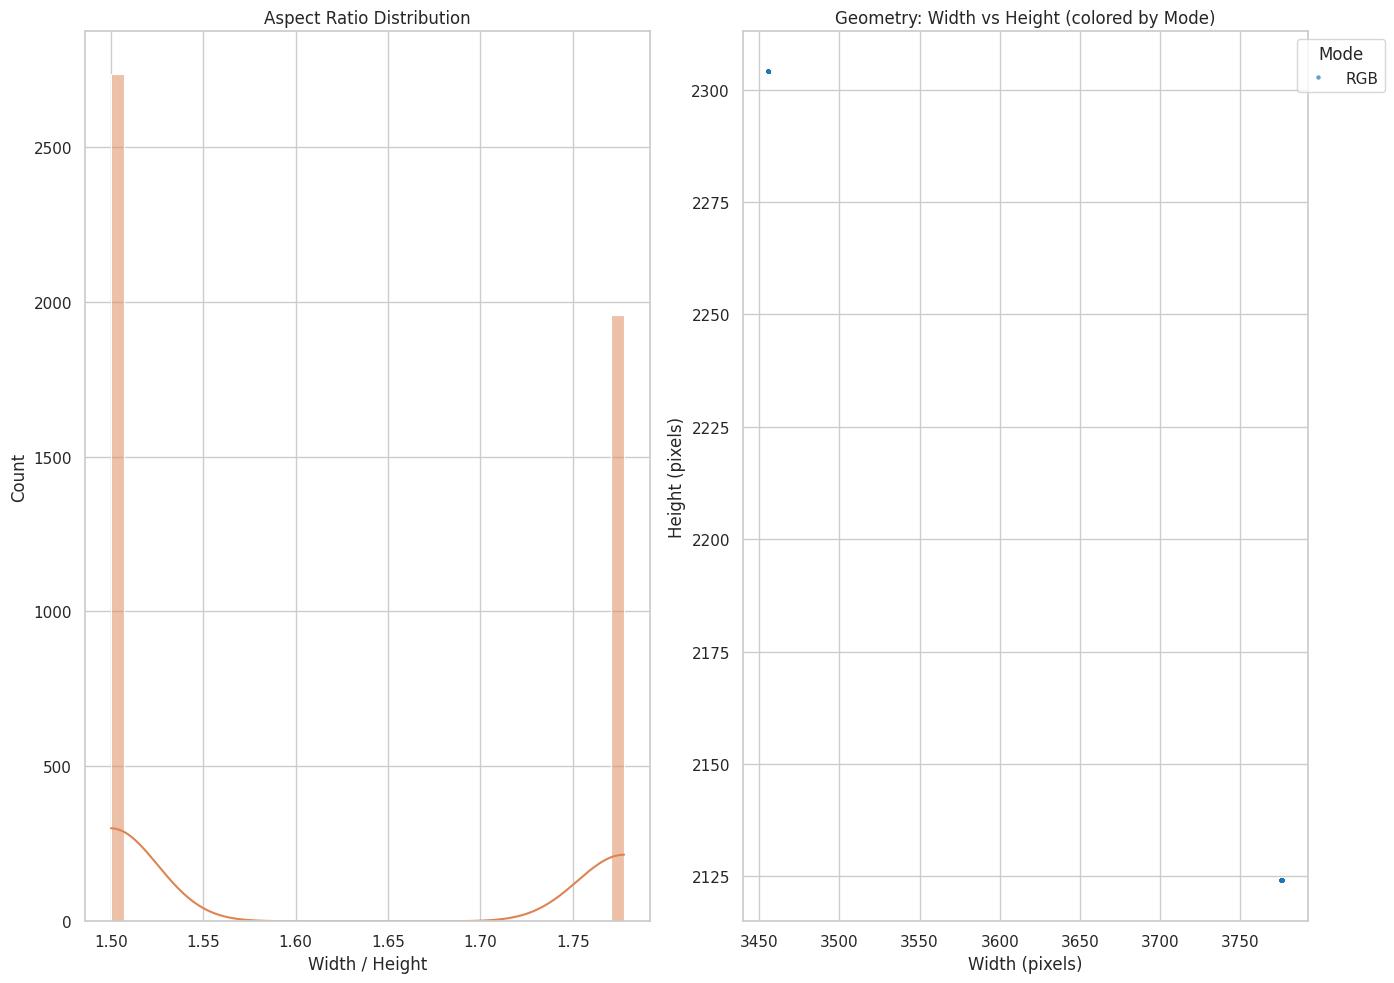

In [25]:
# Calculate Geometry Profiles
df_audit['aspect_ratio'] = df_audit['Width'] / df_audit['Height']
print("\n--- GEOMETRIC FOOTPRINT ---")
print(df_audit[['Width', 'Height', 'aspect_ratio']].describe())

# Visualization dashboard for audit & burst summaries
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Plot for Aspect ratio distribution
ax = axes[0]
sns.histplot(df_audit["aspect_ratio"], bins=40, kde=True, ax=ax, color="C1")
ax.set_title("Aspect Ratio Distribution")
ax.set_xlabel("Width / Height")
ax.set_ylabel("Count")

# Plot for Width vs Height scatter colored by Mode
ax = axes[1]
sns.scatterplot(data=df_audit, x="Width", y="Height", hue="Mode", palette="tab10", s=10, alpha=0.7, ax=ax, linewidth=0)
ax.set_title("Geometry: Width vs Height (colored by Mode)")
ax.set_xlabel("Width (pixels)")
ax.set_ylabel("Height (pixels)")
ax.legend(title="Mode", loc="upper right", bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

#### Notes:
The Aspect Ratio has an average of 1.615 with images having a width of 3456 or 3776 and a height of 2124 or 2304. 

## TARGET 3 : Spatiotemporal Burst and Data Leakage Prevention


--- IDAHO WOLF BURST PATTERNS ---
3     237
4       1
5      36
6     166
9      65
10     13
12     42
15     32
16      1
18     14
20      6
21      6
24      4
25      8
27      1
30      4
33      1
39      1
75      1
Name: count, dtype: int64


Text(0, 0.5, 'Number of sequences')

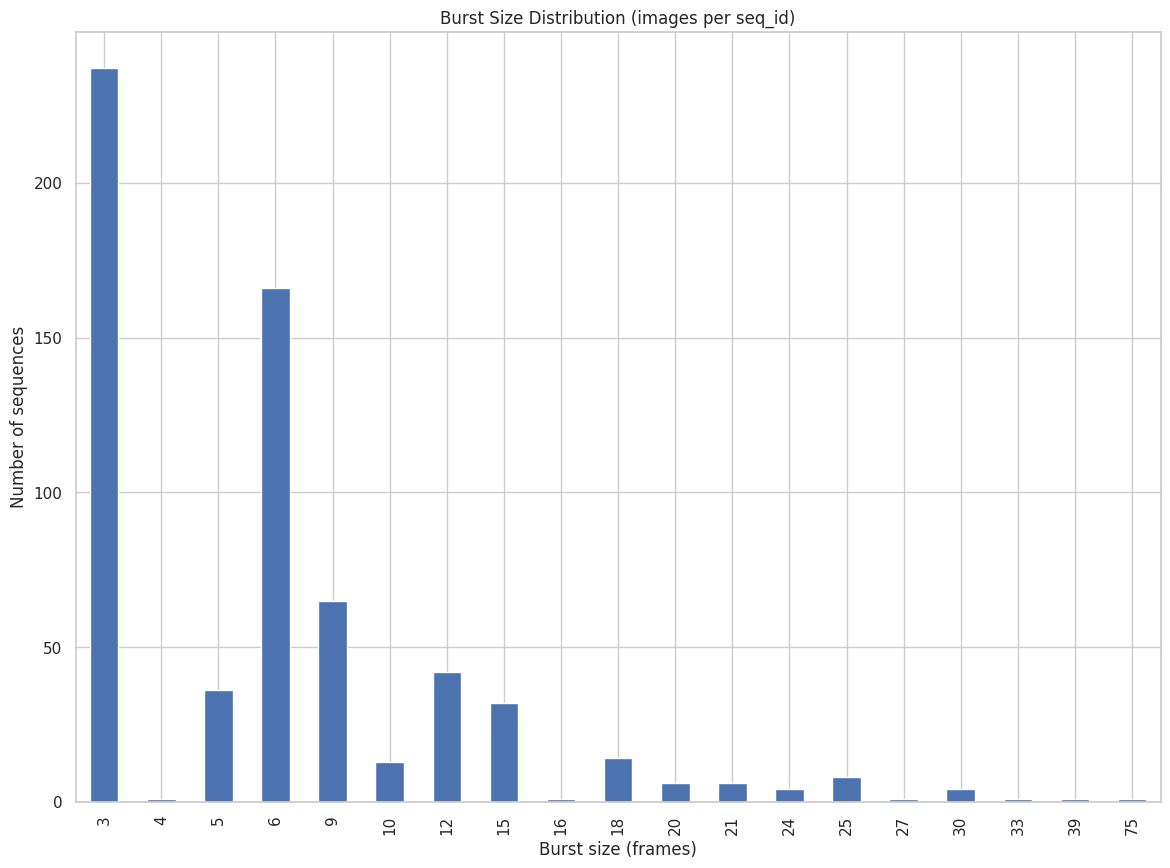

In [19]:
if 'seq_id' in df_wolf.columns:
    burst_data = df_wolf.groupby('seq_id').size().value_counts().sort_index()
    print("\n--- IDAHO WOLF BURST PATTERNS ---")
    print(burst_data)
else:
    # If explicit sequences aren't defined, analyze image capture frequency per location
    print("\nImages captured per geographic location station:")
    print(df_wolf['location'].value_counts().head(10))


# Visualization dashboard for audit & burst summaries
fig, 
# 2) Aspect ratio distribution
ax = axes[0, 1]
sns.histplot(df_audit["aspect_ratio"], bins=40, kde=True, ax=ax, color="C1")
ax.set_title("Aspect Ratio Distribution")
ax.set_xlabel("Width / Height")
axes = plt.subplots(1, 1, figsize=(14, 10))

# Burst size distribution (from burst_data series)
ax = axes
burst_data.sort_index().plot(kind="bar", ax=ax, color="C0")
ax.set_title("Burst Size Distribution (images per seq_id)")
ax.set_xlabel("Burst size (frames)")
ax.set_ylabel("Number of sequences")


## Notes:
None of the images were taken in a single burst. The subset features bursts with more variety than in comparison to the iWildCam2019 dataset. The mainimum amount was 3 images per burst (mode) and the maximum was 75 images per burst.

## Conclusion and Recommendations
This EDA was conducted on the IdahoWolfCam subset of the LILAC BC dataset. The EDA"s purpose was to verify its contents according to how much of the data is RGB or other formats, the size of each image is consitent, and how much of the data belongs to a specific amount of bursts. Based on the findings, the recommendations for developing the model are made below. 

1. All of the images are RGB. This then facilitates the need that the future combined dataset will need to be all in the RGB format.
2. There is more image geometry disparity in the dataset compared to iWildCam2019 dataset, so there should be more consideration on cropping the image appropriately.
3. Split the images by sequence rather than individually.